# Transmitting a digitally modulated signal

The goal of this notebook is to integrate the building blocks for the transmitter and send a digitally modulated signal over the audio channel.

In [1]:
import numpy as np
import sounddevice as sd

# Matplotlib is a plotting library for creating static, animated, and interactive visualizations in Python. The 'inline' magic command allows the plots to be displayed directly in the notebook.
import matplotlib.pyplot as plt
%matplotlib inline

# tweak the appearance of the plots
plt.rcParams['figure.figsize'] = (10, 6)  # Set the default figure size for plots

# seaborn is a statistical data visualization library based on Matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.
import seaborn as sns
# Set the context for Seaborn plots to 'talk', which is suitable for presentations and larger text sizes.
sns_context = 'talk' 
sns.set_theme(context=sns_context, style="ticks", palette="deep")


In [2]:
# import our modules
from dc_632_26.sources import RandomBitSource
from dc_632_26.freq_shift import Upconverter
from dc_632_26.constellations import QPSK
from dc_632_26.modulation import modulation
from dc_632_26.pulse_shaper import PulseShaper
from dc_632_26.pulses import cosine_squared

## Transmitter block

Integrate the building blocks into a transmitter that takes a sequence of bits and produces a modulated signal, including:
* modulation mapping
* pulse shaping
* frequency upconversion

Transmission of the resulting signal is performed via the `sounddevice` library.

For integrating the various building blocks into a complete transmitter, we use the `Transmitter` class defined below. This class is instantiated with a set of parameters, including constellation and pulse. The resulting object can then be used to modulate a sequence of bits into a passband signal ready for transmission.

In [ ]:
class Transmitter:
    """Class that represents a digital transmitter with modulation mapping, pulse shaping and upconversion.

    Parameters
    ----------
    fc : float
        Carrier frequency
    fs : float
        Sampling frequency
    constellation : object
        Constellation object for modulation
    pulse_shape : function
        Pulse shaping function
    fsT : float
        Oversampling factor for the pulse shaper
    """
    def __init__(self, fc: float, fs: float, constellation, pulse_shape, fsT: float):
        """Initialize the transmitter with carrier frequency, sampling frequency, constellation, pulse shaping function, and oversampling factor."""
        self.fc = fc
        self.fs = fs
        self.uc = Upconverter(fc, fs)
        self.constellation = constellation
        self.pulseShaper = PulseShaper(pulse_shape, fsT)
        # add constellation and pulse shaping parameters here

    def modulate(self, bits: np.ndarray) -> np.ndarray:
        """Modulate the given bits into a passband signal using the transmitter's parameters.

        Parameters
        ----------
        bits : np.ndarray
            Array of input bits to be modulated.

        Returns
        -------
        np.ndarray
            Upconverted passband signal.
        """
        # map bits to symbols
        symbols = modulation(bits, self.constellation)

        # pulse shaping
        bb_signal = self.pulseShaper.generate_waveform(symbols)

        # upconvert
        upconverted_signal = self.uc.process(bb_signal)

        return upconverted_signal


In [ ]:
## Instantiate and use the transmitter
# Transmitter parameters
fc = 10e3
fs = 48e3
fsT = 64
constellation = QPSK
pulse_shape = cosine_squared

# Create the transmitter instance
tx = Transmitter(fc, fs, constellation, pulse_shape, fsT)

# Generate random bits and modulate them into a passband signal
bits = RandomBitSource().get_bits(1000)
signal = tx.modulate(bits)

In [15]:
# Make a note of the first few bits
first_few_bits = bits[:32]
print("First few transmitted bits:", first_few_bits)

First few transmitted bits: [1 1 1 1 1 0 1 0 0 0 1 0 0 0 1 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 1 1]


In [9]:
## send and receive signals via audio
# to prevent the recorded signal from being cut-off, append some zeros to the transmitted signal
recorded_signal = sd.playrec(np.concatenate([signal, np.zeros(int(0.3*fs))]), fs, channels=1)

sd.wait()  # wait until playback and recording is finished

The received signal (`recorded_signal`) is now available for analysis. Ultimately, we would like to be able to demodulate it and recover the transmitted bits. We will see that we need to do some work before that will succeed.

However, we can still visualize and analyze the received signal to gain insights into its characteristics.
For example, we can plot the time-domain waveform and the frequency spectrum of the received signal.

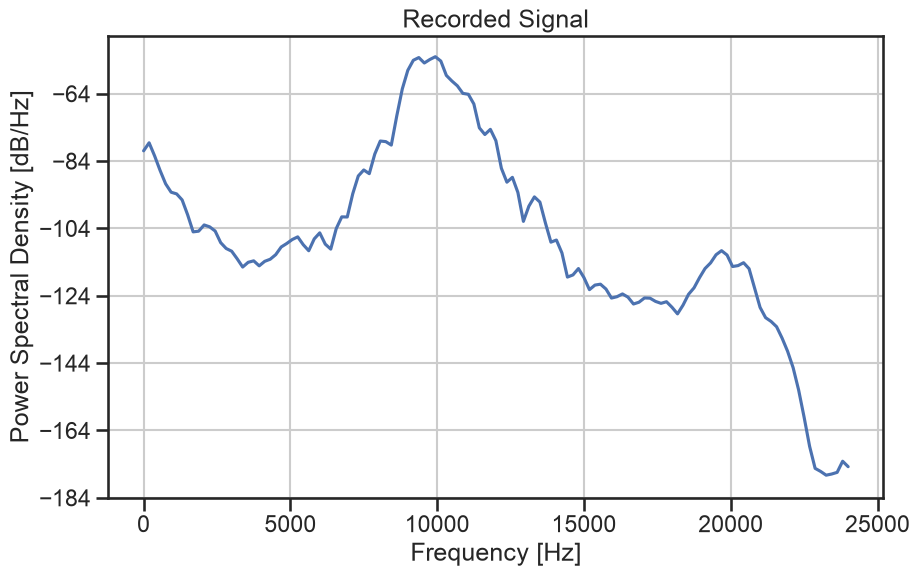

In [10]:
## look at the PSD ...
plt.psd(recorded_signal[:, 0], Fs=fs)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power Spectral Density [dB/Hz]')
plt.title('Recorded Signal')
plt.show()

That looks reasonable. We can clearly see the signal at the carrier frequency. With the selected parameters, the symbol rate is $fs/fsT = 48\text{ KHz}/64 = 750 \text{ Hz}$. The bandwidth of the main lobe at 10KHz looks approximately right - you will investigate this further when analyzing the frequency spectrum in more detail.

We also see the interference at low frequencies from noise in the environments (AC fans and such). It is not clear why there is a frequency component at twice the carrier frequency; fortunately that component is 40dB weaker than the main lobe.

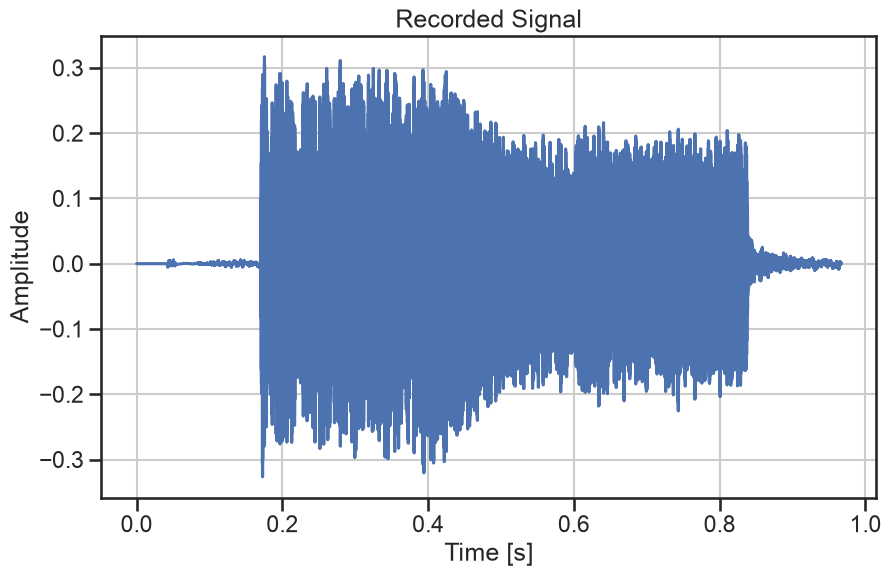

In [13]:
## and the time-domain signal
plt.plot(np.arange(len(recorded_signal)) / fs, recorded_signal[:, 0])
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Recorded Signal')
#plt.xlim(0.4, .41)
plt.grid()
plt.show()

The time-domain waveform of the received signal is clearly visible. It is preceded and followed by (more or less) silence, which corresponds to the periods before and after the actual transmission. 

The 1000 transmitted bits are mapped to 500 QPSK symbols. With a symbol rate of 750 Hz, the duration of the actual transmission is approximately 500/750 ≈ 0.67 seconds - which agrees with the observed length of the signal in the time-domain waveform.

The amplitude of the received signal varies slightly over the duration of the transmission. It is unclear why that occurs.

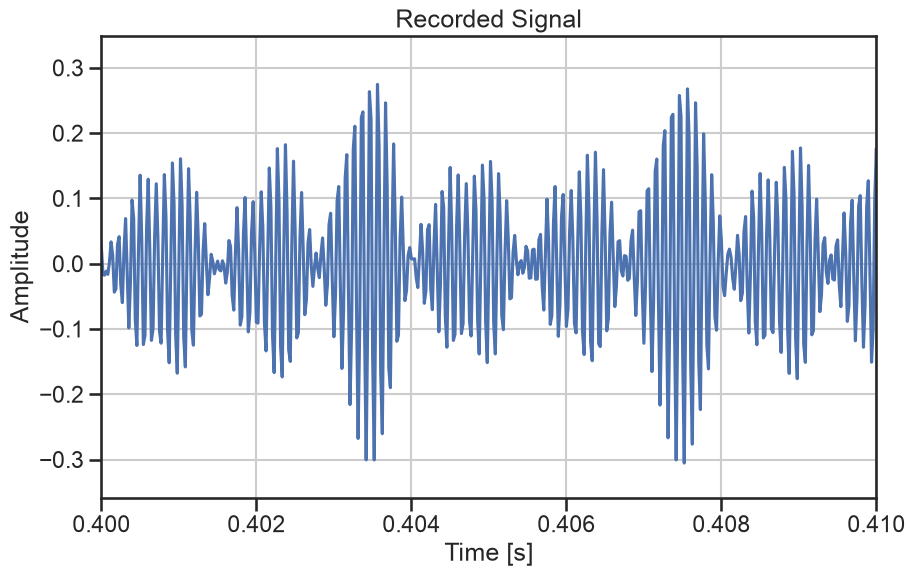

In [14]:
## zoom in on time-domain signal
plt.plot(np.arange(len(recorded_signal)) / fs, recorded_signal[:, 0])
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Recorded Signal')
plt.xlim(0.4, .41)
plt.grid()
plt.show()

Zooming in on 100ms of the recorded signal, we can discern the individual QPSK symbols and recognize the pulse shape. The amplitude variations are visible at this scale as well. During these 100ms, we observe approximately 7.5 symbols, which is consistent with the symbol rate of 750 Hz. 

At the boundaries between symbols, we can observe discontinuities in the carrier signal that correspond to changes in the QPSK constellation points. 


All of these observations, suggest that we have received a reasonable clean signal that accurately represents the transmitted QPSK symbols. We should be able to receive and demodulate the transmitted data successfully - right?

In [16]:
# store the first few transmitted bits and the recorded signal for off-line analysis
np.save("data/10_transmitter_first_few_bits.npy", first_few_bits)
np.save("data/10_recorded_signal.npy", recorded_signal)